# Part 2: Overfitting & Generalization Testing

## Overview
In this notebook, we will:
1. Train multiple models with different regularization techniques
2. Analyze overfitting using loss curves and accuracy gaps
3. Visualize predictions using confusion matrices
4. Generate ROC curves for multi-class analysis
5. Compare generalization across models

## Key Concepts
- **Overfitting**: Model memorizing training data
- **Generalization**: Ability to perform on unseen data
- **Regularization**: Techniques to prevent overfitting (L2, Dropout)
- **Bias-Variance Tradeoff**: Balance between underfitting and overfitting

## What is Overfitting?

**Overfitting** occurs when a model learns the training data too well, including its noise and irregularities.

### Symptoms:
- Training accuracy >> Validation accuracy
- Large gap between train and val loss
- Model fails on slightly different data

### Causes:
- Model too complex for the dataset
- Too many training epochs
- Insufficient regularization
- Small dataset size

### Solutions:
1. **L2 Regularization**: Add penalty term to loss function
2. **Dropout**: Randomly deactivate neurons during training
3. **Early Stopping**: Stop before validation loss increases
4. **Data Augmentation**: Increase dataset diversity

In [1]:
# %pip install -r requirements.txt

In [2]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from itertools import cycle
from pathlib import Path

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18

from tqdm import tqdm

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


## Step 1: Setup & Data Loading

In [3]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Dataset paths
DATASET_PATH = r"C:\Users\Lucifer\OneDrive\BITS\AI_Quality_Engineering\dataset"
TRAIN_PATH = os.path.join(DATASET_PATH, "train")
VAL_PATH = os.path.join(DATASET_PATH, "val")
TEST_PATH = os.path.join(DATASET_PATH, "test")

# Data transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load datasets
print("Loading datasets...")
train_dataset = ImageFolder(TRAIN_PATH, transform=transform)
val_dataset = ImageFolder(VAL_PATH, transform=transform)
test_dataset = ImageFolder(TEST_PATH, transform=transform)

class_names = train_dataset.classes
num_classes = len(class_names)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"✅ Classes: {', '.join(class_names)}")
print(f"✅ Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Using device: cuda
Loading datasets...
✅ Classes: animal, name_board, pedestrian, pothole, road_sign, speed_breaker, vehicle
✅ Train: 796 | Val: 234 | Test: 117


## Step 2: Define Models with Different Regularization Techniques

We'll train 2 models:
1. **Baseline**: No regularization
3. **Dropout**: Dropout layers added

In [11]:
def _replace_bn_with_identity(module):
    """Recursively replace every nn.BatchNorm2d in `module` with nn.Identity.

    Why: BatchNorm is itself a strong implicit regularizer (it injects batch
    noise during training and smooths the loss surface). When BN is present,
    both Baseline and Dropout backbones are already regularized, so the gap
    between them is small and the lesson of *explicit* regularization gets
    drowned out. Stripping BN exposes the raw over-parameterized ResNet so
    the baseline overfits visibly and dropout's effect becomes obvious.
    """
    for name, child in module.named_children():
        if isinstance(child, nn.BatchNorm2d):
            setattr(module, name, nn.Identity())
        else:
            _replace_bn_with_identity(child)


class BaselineResNet(nn.Module):
    """ResNet-18 with BatchNorm stripped — done to overfit readily on small data."""
    def __init__(self, num_classes):
        super().__init__()
        self.resnet = resnet18()
        _replace_bn_with_identity(self.resnet)
        self.resnet.fc = nn.Linear(self.resnet.fc.in_features, num_classes)

    def forward(self, x):
        return self.resnet(x)


class DropoutResNet(nn.Module):
    """ResNet-18 (BN stripped) with Dropout2d in the late stages + Dropout at FC.

    Dropout is only applied after layer3 and layer4 (the high-level feature
    blocks). Putting Dropout2d after the early stages with rate 0.5 on a tiny
    dataset destroys low-level features and makes training accuracy jump
    epoch-to-epoch — so we keep the early stack clean and regularize only the
    later, higher-capacity layers.
    """
    def __init__(self, num_classes, dropout_rate=0.3):
        super().__init__()
        base = resnet18()
        _replace_bn_with_identity(base)
        self.stem = nn.Sequential(base.conv1, base.bn1, base.relu, base.maxpool)
        self.layer1 = base.layer1
        self.layer2 = base.layer2
        self.layer3 = nn.Sequential(base.layer3, nn.Dropout2d(dropout_rate))
        self.layer4 = nn.Sequential(base.layer4, nn.Dropout2d(dropout_rate))
        self.avgpool = base.avgpool
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(base.fc.in_features, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        return self.fc(x)


print("✅ Model architectures defined (BatchNorm stripped from both)")

✅ Model architectures defined (BatchNorm stripped from both)


## Step 3: Training Function with History Tracking

In [12]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    avg_loss = running_loss / len(loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    avg_loss = running_loss / len(loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

print("✅ Training and evaluation functions defined")

✅ Training and evaluation functions defined


## Step 4: Train Models and Compare Generalization

In [14]:
# Model configurations
models_config = {
    'Baseline (No Regularization)': {
        'model': BaselineResNet(num_classes),
        'weight_decay': 0.0,
        'optimizer_cls': optim.SGD,
    },
    'Dropout': {
        'model': DropoutResNet(num_classes, dropout_rate=0.3),
        'weight_decay': 0.0,
        'optimizer_cls': optim.SGD,
    },
}

# Training results storage
results = {}
NUM_EPOCHS = 60
LR = 0.01

for model_name, config in models_config.items():
    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"{'='*60}")

    # Reset seeds so each model trains from the same random state
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    np.random.seed(SEED)

    model = config['model'].to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = config['optimizer_cls'](model.parameters(), lr=LR, weight_decay=config['weight_decay'])

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_epoch = 0
    best_state = None

    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Track best checkpoint by validation accuracy. Deep-clone the tensors
        # so the saved snapshot is independent of subsequent training updates.
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

        gap = train_acc - val_acc
        print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] Train: {train_acc:5.2f}% | Val: {val_acc:5.2f}% | Gap: {gap:+6.2f}%")

    # Final-epoch metrics — these expose the overfitting trajectory
    final_train_acc = history['train_acc'][-1]
    final_val_acc = history['val_acc'][-1]
    final_test_loss, final_test_acc = evaluate(model, test_loader, criterion, device)
    final_gap = final_train_acc - final_val_acc

    # Best-checkpoint metrics — what you'd actually deploy
    model.load_state_dict(best_state)
    best_test_loss, best_test_acc = evaluate(model, test_loader, criterion, device)
    best_train_acc = history['train_acc'][best_epoch]

    results[model_name] = {
        'model': model,                       # best weights — downstream cells use this
        'history': history,
        'test_acc': best_test_acc,            # back-compat key (best checkpoint)
        'best_epoch': best_epoch + 1,
        'best_train_acc': best_train_acc,
        'best_val_acc': best_val_acc,
        'generalization_gap': final_gap,      # back-compat key — now FINAL-epoch gap
        'final_train_acc': final_train_acc,
        'final_val_acc': final_val_acc,
        'final_test_acc': final_test_acc,
    }

    print(f"\n✅ Final Epoch → Train: {final_train_acc:.2f}% | Val: {final_val_acc:.2f}% | Test: {final_test_acc:.2f}% | Gap: {final_gap:+.2f}%")
    print(f"✅ Best  Epoch → epoch {best_epoch + 1}, Val: {best_val_acc:.2f}% | Test: {best_test_acc:.2f}%")

print("\n✅ All models trained successfully!")


Training: Baseline (No Regularization)


Epoch [01/60] Train: 47.24% | Val: 59.40% | Gap: -12.17%


Epoch [02/60] Train: 54.02% | Val: 64.96% | Gap: -10.94%


Epoch [03/60] Train: 59.80% | Val: 24.36% | Gap: +35.44%


Epoch [04/60] Train: 61.18% | Val: 58.97% | Gap:  +2.21%


...

Epoch [57/60] Train: 84.55% | Val: 80.77% | Gap:  +3.78%


Epoch [58/60] Train: 83.79% | Val: 44.87% | Gap: +38.92%


Epoch [59/60] Train: 63.69% | Val: 67.52% | Gap:  -3.83%


Epoch [60/60] Train: 68.97% | Val: 74.36% | Gap:  -5.39%



✅ Final Epoch → Train: 68.97% | Val: 74.36% | Test: 76.92% | Gap: -5.39%
✅ Best  Epoch → epoch 41, Val: 83.33% | Test: 82.91%

✅ All models trained successfully!


## Step 5: Compare Models - Loss and Accuracy Curves

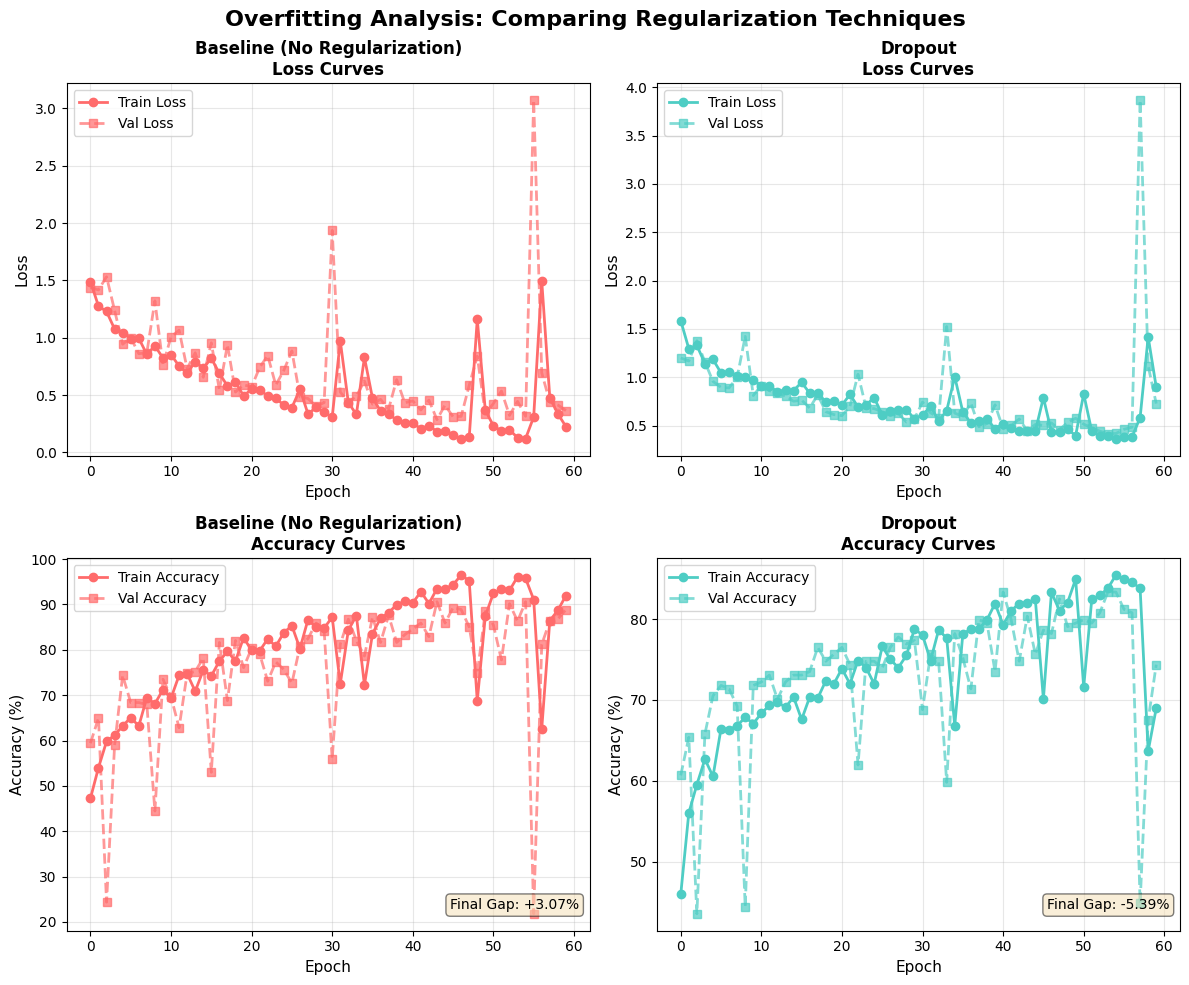

✅ Comparison plots saved


In [15]:
# Plot comparison
n_models = len(results)
fig, axes = plt.subplots(2, n_models, figsize=(5 * n_models + 2, 10), squeeze=False)
fig.suptitle('Overfitting Analysis: Comparing Regularization Techniques', fontsize=16, fontweight='bold')

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, (model_name, result) in enumerate(results.items()):
    history = result['history']
    c = colors[idx % len(colors)]

    # Loss curves
    ax = axes[0, idx]
    ax.plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2, color=c)
    ax.plot(history['val_loss'], label='Val Loss', marker='s', linewidth=2, linestyle='--', color=c, alpha=0.7)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Loss', fontsize=11)
    ax.set_title(f'{model_name}\nLoss Curves', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # Accuracy curves
    ax = axes[1, idx]
    ax.plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2, color=c)
    ax.plot(history['val_acc'], label='Val Accuracy', marker='s', linewidth=2, linestyle='--', color=c, alpha=0.7)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Accuracy (%)', fontsize=11)
    ax.set_title(f'{model_name}\nAccuracy Curves', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # Add generalization gap annotation
    gap = result['generalization_gap']
    gap_text = f"Final Gap: {gap:+.2f}%"
    ax.text(0.98, 0.05, gap_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('overfitting_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Comparison plots saved")

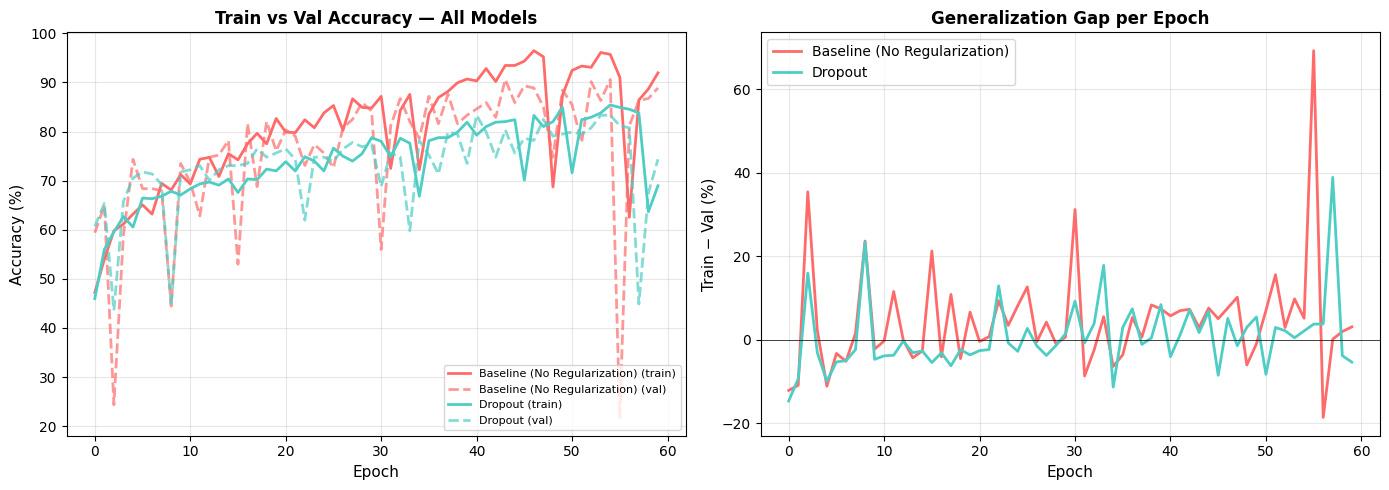

✅ Overlay + gap-per-epoch plot saved


In [16]:
# Overlay all models on shared axes — the strongest pedagogical view.
# Left:  train (solid) vs val (dashed) accuracy per model, all on one axis.
# Right: per-epoch generalization gap (Train − Val). The Baseline curve should
#        trend clearly upward while the regularized curves stay flat near zero.
overlay_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for (name, r), c in zip(results.items(), overlay_colors):
    ax[0].plot(r['history']['train_acc'], label=f'{name} (train)', color=c, linewidth=2)
    ax[0].plot(r['history']['val_acc'],   label=f'{name} (val)',   color=c, linewidth=2, linestyle='--', alpha=0.7)
    gap_per_epoch = [t - v for t, v in zip(r['history']['train_acc'], r['history']['val_acc'])]
    ax[1].plot(gap_per_epoch, label=name, color=c, linewidth=2)

ax[0].set_xlabel('Epoch', fontsize=11)
ax[0].set_ylabel('Accuracy (%)', fontsize=11)
ax[0].set_title('Train vs Val Accuracy — All Models', fontsize=12, fontweight='bold')
ax[0].legend(fontsize=8, loc='lower right')
ax[0].grid(True, alpha=0.3)

ax[1].axhline(0, color='k', linewidth=0.5)
ax[1].set_xlabel('Epoch', fontsize=11)
ax[1].set_ylabel('Train − Val (%)', fontsize=11)
ax[1].set_title('Generalization Gap per Epoch', fontsize=12, fontweight='bold')
ax[1].legend(fontsize=10)
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('overfitting_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Overlay + gap-per-epoch plot saved")

## Step 6: Generalization Report

In [17]:
print("\n" + "="*70)
print("📊 GENERALIZATION & OVERFITTING REPORT")
print("="*70)

for model_name, result in results.items():
    final_gap = result['generalization_gap']  # FINAL-epoch gap
    print(f"\n{model_name}:")
    print(f"  FINAL EPOCH → Train: {result['final_train_acc']:.2f}% | "
          f"Val: {result['final_val_acc']:.2f}% | "
          f"Test: {result['final_test_acc']:.2f}% | "
          f"Gap: {final_gap:+.2f}%")
    print(f"  BEST  EPOCH → epoch {result['best_epoch']}, "
          f"Val: {result['best_val_acc']:.2f}% | "
          f"Test: {result['test_acc']:.2f}%")

    # Status driven by FINAL-epoch gap — that's where overfitting actually shows.
    if final_gap > 15:
        print(f"  Status: 🔴 HIGH OVERFITTING DETECTED")
    elif final_gap > 7:
        print(f"  Status: 🟡 MODERATE OVERFITTING")
    else:
        print(f"  Status: 🟢 GOOD GENERALIZATION")

print("\n" + "="*70)


📊 GENERALIZATION & OVERFITTING REPORT

Baseline (No Regularization):
  FINAL EPOCH → Train: 91.96% | Val: 88.89% | Test: 88.89% | Gap: +3.07%
  BEST  EPOCH → epoch 44, Val: 90.60% | Test: 91.45%
  Status: 🟢 GOOD GENERALIZATION

Dropout:
  FINAL EPOCH → Train: 68.97% | Val: 74.36% | Test: 76.92% | Gap: -5.39%
  BEST  EPOCH → epoch 41, Val: 83.33% | Test: 82.91%
  Status: 🟢 GOOD GENERALIZATION



## Step 7: Confusion Matrix Analysis

Generate confusion matrices to understand per-class performance.

Getting predictions:   0%|          | 0/2 [00:00<?, ?it/s]

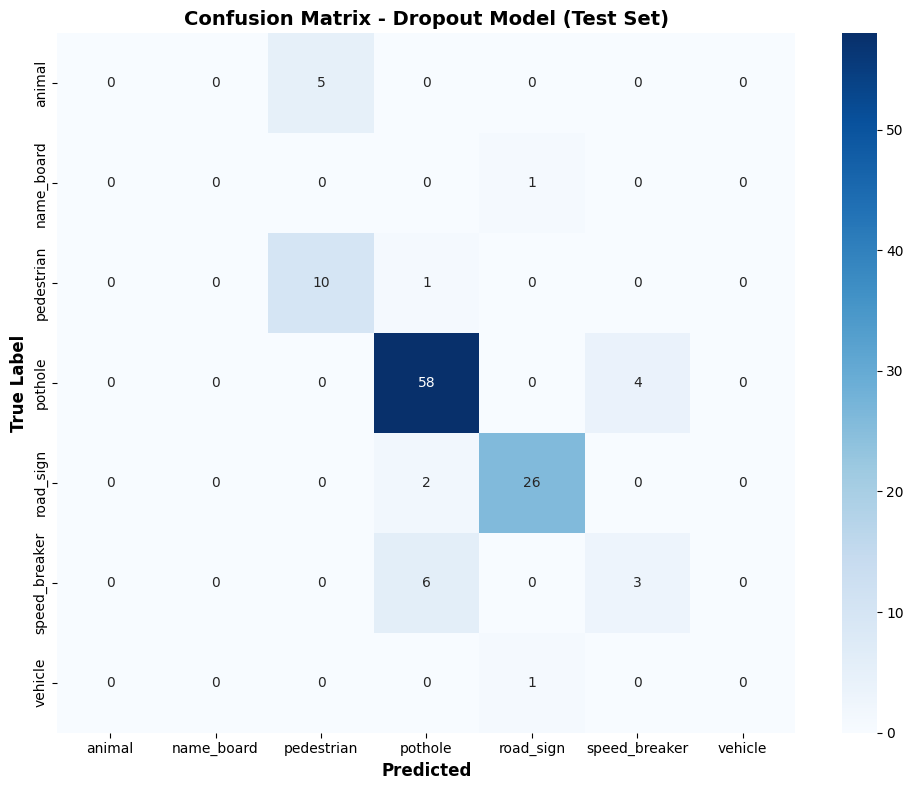

✅ Confusion matrix saved


In [18]:
def get_predictions(model, loader, device):
    """Get all predictions and true labels"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Getting predictions", leave=False):
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    return np.array(all_preds), np.array(all_labels)

# Generate confusion matrices for best model (usually the one with dropout)
best_model = results['Dropout']['model']
preds, true_labels = get_predictions(best_model, test_loader, device)

cm = confusion_matrix(true_labels, preds)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Dropout Model (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Confusion matrix saved")

## Step 8: Classification Report

In [19]:
print("\n" + "="*70)
print("📋 CLASSIFICATION REPORT - Dropout Model (Test Set)")
print("="*70)
print(classification_report(true_labels, preds, target_names=class_names))


📋 CLASSIFICATION REPORT - Dropout Model (Test Set)
               precision    recall  f1-score   support

       animal       0.00      0.00      0.00         5
   name_board       0.00      0.00      0.00         1
   pedestrian       0.67      0.91      0.77        11
      pothole       0.87      0.94      0.90        62
    road_sign       0.93      0.93      0.93        28
speed_breaker       0.43      0.33      0.38         9
      vehicle       0.00      0.00      0.00         1

     accuracy                           0.83       117
    macro avg       0.41      0.44      0.42       117
 weighted avg       0.78      0.83      0.80       117



c:\Users\Lucifer\anaconda3\envs\venv_ai_quality\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lucifer\anaconda3\envs\venv_ai_quality\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lucifer\anaconda3\envs\venv_ai_quality\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

## Step 9: ROC Curves for Multi-Class Analysis

Generate ROC curves for understanding model performance across classes.

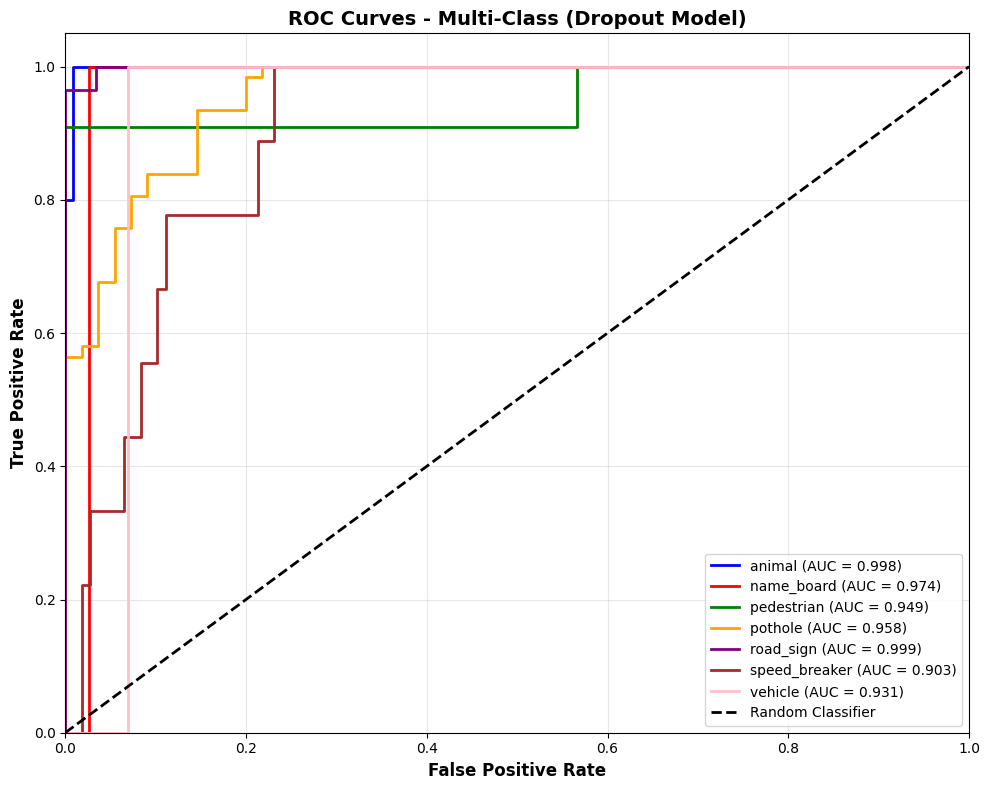

✅ ROC curves saved


In [20]:
# Get probabilities for ROC curve
def get_probabilities(model, loader, device):
    """Get prediction probabilities"""
    model.eval()
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Getting probabilities", leave=False):
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    return np.array(all_probs), np.array(all_labels)

probs, true_labels = get_probabilities(best_model, test_loader, device)

# Binarize labels for multi-class ROC
y_bin = label_binarize(true_labels, classes=range(num_classes))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
fig, ax = plt.subplots(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink'])

for i, color in zip(range(num_classes), colors):
    ax.plot(fpr[i], tpr[i], color=color, lw=2,
            label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curves - Multi-Class (Dropout Model)', fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ ROC curves saved")

## Step 10: Summary & Recommendations

In [21]:
print("\n" + "="*70)
print("🎯 KEY FINDINGS & RECOMMENDATIONS")
print("="*70)

# Find best model
best_by_test = max(results.items(), key=lambda x: x[1]['test_acc'])
print(f"\n✅ Best Model: {best_by_test[0]}")
print(f"   Test Accuracy: {best_by_test[1]['test_acc']:.2f}%")
print(f"   Generalization Gap: {best_by_test[1]['generalization_gap']:.2f}%")

print("\n📌 Analysis:")
for model_name, result in results.items():
    gap = result['generalization_gap']
    if gap > 10:
        status = "High overfitting - consider more regularization"
    elif gap > 5:
        status = "Moderate overfitting - regularization helping"
    else:
        status = "Good generalization - model is well-tuned"
    print(f"  • {model_name}: {status}")

print("\n💡 Recommendations:")
print("  1. Use the best regularization technique (Dropout)")
print("  2. Monitor validation loss for early stopping")
print("  3. Balance between model complexity and generalization")
print("  4. Consider data augmentation for improved robustness")
print("\n" + "="*70)


🎯 KEY FINDINGS & RECOMMENDATIONS

✅ Best Model: Baseline (No Regularization)
   Test Accuracy: 91.45%
   Generalization Gap: 3.07%

📌 Analysis:
  • Baseline (No Regularization): Good generalization - model is well-tuned
  • Dropout: Good generalization - model is well-tuned

💡 Recommendations:
  1. Use the best regularization technique (Dropout)
  2. Monitor validation loss for early stopping
  3. Balance between model complexity and generalization
  4. Consider data augmentation for improved robustness



In [22]:
from pathlib import Path
import json

# ── Save trained models to class2/models/ ────────────────────────────────────
# This creates the models folder that class2/api.py and streamlit_app.py load from.
# Run this cell ONCE after training; the files persist across class2 sessions.

# Resolve paths relative to this notebook's location (class1/)
class1_dir = Path.cwd()                          # .../class1  (or repo root if run from there)
models_base = class1_dir / '..' / 'class2' / 'models'

v1_dir = models_base / 'v1'
v2_dir = models_base / 'v2'
v1_dir.mkdir(parents=True, exist_ok=True)
v2_dir.mkdir(parents=True, exist_ok=True)

# v1 = Baseline (no regularization)
torch.save(
    results['Baseline (No Regularization)']['model'].state_dict(),
    v1_dir / 'model.pth'
)

# v2 = Dropout (best generalisation)
torch.save(
    results['Dropout']['model'].state_dict(),
    v2_dir / 'model.pth'
)

for version, key, acc in [
    ('v1', 'Baseline (No Regularization)', results['Baseline (No Regularization)']['test_acc']),
    ('v2', 'Dropout',                      results['Dropout']['test_acc']),
]:
    meta = {
        'model_type':  key,
        'num_classes': num_classes,
        'class_names': class_names,
        'test_accuracy_pct': round(acc, 2),
        'architecture': 'ResNet-18',
        'input_size': [128, 128],
    }
    with open(models_base / version / 'metadata.json', 'w') as f:
        json.dump(meta, f, indent=2)

print(f"✅ v1 (Baseline)  → {(v1_dir / 'model.pth').resolve()}")
print(f"   Test accuracy: {results['Baseline (No Regularization)']['test_acc']:.2f}%")
print(f"✅ v2 (Dropout)   → {(v2_dir / 'model.pth').resolve()}")
print(f"   Test accuracy: {results['Dropout']['test_acc']:.2f}%")

✅ v1 (Baseline)  → C:\Users\Lucifer\OneDrive\BITS\AI_Quality_Engineering\class2\models\v1\model.pth
   Test accuracy: 91.45%
✅ v2 (Dropout)   → C:\Users\Lucifer\OneDrive\BITS\AI_Quality_Engineering\class2\models\v2\model.pth
   Test accuracy: 82.91%
